# Preprocessing and Windowing - Daphnet FoG Dataset

**Objective:** Prepare data for FoG detection through label creation, sliding windows, and LOSO splits.

**Process:**
1. Load dataset
2. Create binary and multiclass labels
3. Generate sliding windows (4s, 50% overlap)
4. Create LOSO splits
5. Save windowed data

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut
import pickle

from loaders import DaphnetDatasetLoader
from processing import LabelCreator, WindowCreator
from utils.constants import SAMPLING_RATE, WINDOW_SIZE_SEC, WINDOW_OVERLAP, FEATURE_COLUMNS
from utils.visualization import plot_label_distribution, plot_window_example

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Dataset

In [2]:
# Load data
loader = DaphnetDatasetLoader('../../Datasets/Daphnet fog/dataset')
df = loader.load_all_data(verbose=True)

# Add subject and trial identifiers
df['subject'] = df['subject_id'].apply(lambda x: f'S{x:02d}')
df['trial'] = df['run_id'].apply(lambda x: f'R{x:02d}')

# Filter experimental data only (annotation != 0)
df = df[df['annotation'] != 0].reset_index(drop=True)

print(f"\nDataset shape: {df.shape}")
print(f"Subjects: {sorted(df['subject'].unique())}")
print(f"Total samples: {len(df):,}")

📁 Encontrados 17 archivos
📊 Cargando datos del dataset Daphnet...



Cargando archivos:   0%|          | 0/17 [00:00<?, ?it/s]

Cargando archivos: 100%|██████████| 17/17 [00:21<00:00,  1.26s/it]



✅ Dataset cargado exitosamente

RESUMEN DEL DATASET: DaphnetDatasetLoader

📊 Información General:
   Dimensiones: (1917887, 16)
   Filas: 1,917,887
   Columnas: 16
   Memoria: 327.40 MB

👥 Sujetos: 10
📁 Archivos: 17

🚨 Episodios de FoG:
   Muestras con FoG: 110,785 (5.78%)
   Muestras sin FoG: 1,807,102 (94.22%)


Dataset shape: (1140835, 18)
Subjects: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']
Total samples: 1,140,835


## 2. Create Labels

Binary labels: 0=No FoG, 1=FoG  
Multiclass labels: 0=No FoG, 1=FoG, 2=Pre-FoG (0.5s before onset)

In [3]:
# Create labels
label_creator = LabelCreator(
    annotation_col='annotation',
    subject_col='subject',
    trial_col='trial',
    pre_fog_window_sec=0.5,
    sampling_rate=SAMPLING_RATE
)

df = label_creator.create_all_labels(df, include_pre_fog=True)

print("Label creation complete.")
print(f"\nBinary distribution:")
print(label_creator.get_label_distribution(df['binary_label'], 'binary'))
print(f"\nMulticlass distribution:")
print(label_creator.get_label_distribution(df['multiclass_label'], 'multiclass'))

Label creation complete.

Binary distribution:
                count  percentage label_name
binary_label                                
0             1030050       90.29     No FoG
1              110785        9.71        FoG

Multiclass distribution:
                    count  percentage label_name
multiclass_label                                
0                 1022466       89.62     No FoG
1                  110785        9.71        FoG
2                    7584        0.66    Pre-FoG


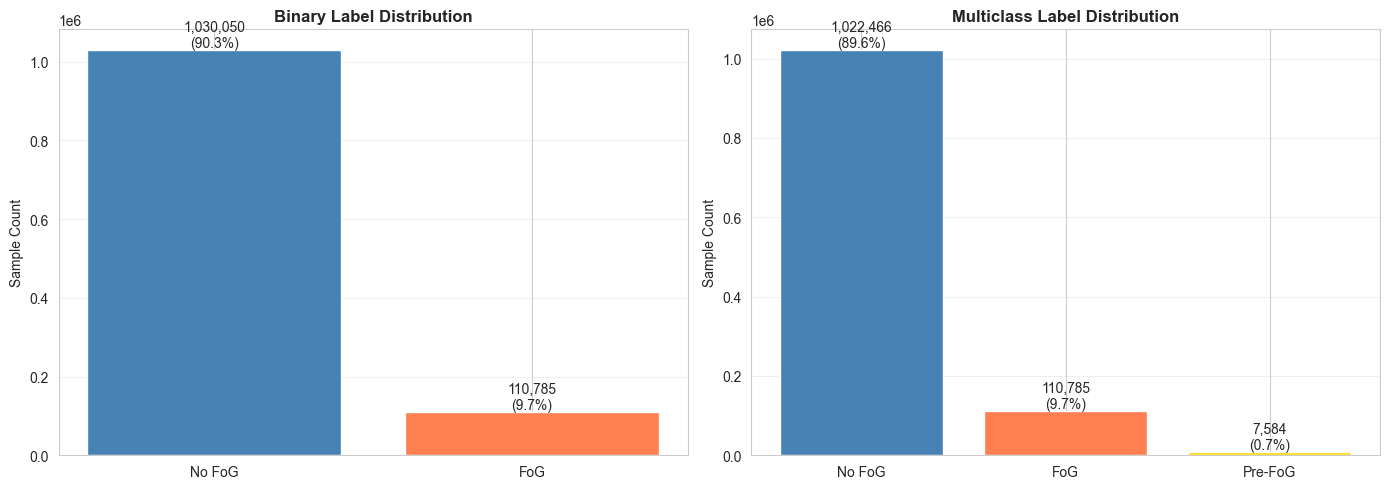

In [4]:
# Visualize label distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary
binary_counts = df['binary_label'].value_counts().sort_index()
axes[0].bar(['No FoG', 'FoG'], binary_counts.values, color=['steelblue', 'coral'])
axes[0].set_ylabel('Sample Count')
axes[0].set_title('Binary Label Distribution', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(binary_counts.values):
    pct = v / len(df) * 100
    axes[0].text(i, v, f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom')

# Multiclass
multi_counts = df['multiclass_label'].value_counts().sort_index()
axes[1].bar(['No FoG', 'FoG', 'Pre-FoG'], multi_counts.values, 
           color=['steelblue', 'coral', 'gold'])
axes[1].set_ylabel('Sample Count')
axes[1].set_title('Multiclass Label Distribution', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(multi_counts.values):
    pct = v / len(df) * 100
    axes[1].text(i, v, f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 3. Create Sliding Windows

Window configuration: 4 seconds (256 samples), 50% overlap (128-sample steps)  
Windows are created per subject/trial to maintain temporal continuity.

In [ ]:
# Initialize window creators
WINDOW_OVERLAP_TRAIN = 0.5  # 50% overlap for training
WINDOW_OVERLAP_TEST = 0.0   # 0% overlap for testing (no temporal correlation)

window_creator_train = WindowCreator(
    window_size=WINDOW_SIZE_SEC,
    overlap=WINDOW_OVERLAP_TRAIN,
    sampling_rate=SAMPLING_RATE
)

window_creator_test = WindowCreator(
    window_size=WINDOW_SIZE_SEC,
    overlap=WINDOW_OVERLAP_TEST,
    sampling_rate=SAMPLING_RATE
)

# Alias for visualization cells below
window_creator = window_creator_train

# Display configuration
config = window_creator_train.get_window_info()
print("Window Configuration:")
print(f"  Duration: {config['window_size_sec']} seconds")
print(f"  Samples: {config['window_samples']}")
print(f"  Train overlap: {WINDOW_OVERLAP_TRAIN*100:.0f}% (step: {config['step_samples']} samples)")
print(f"  Test overlap:  {WINDOW_OVERLAP_TEST*100:.0f}% (no temporal correlation between test windows)")

In [ ]:
# Create windows for one subject (visualization only)
print("Creating sample windows for visualization (S01)...")

subject_sample = 'S01'
df_sample = df[df['subject'] == subject_sample].reset_index(drop=True)

result_sample = window_creator_train.create_windows_from_df(
    df=df_sample,
    feature_cols=FEATURE_COLUMNS,
    binary_label_col='binary_label',
    multiclass_label_col='multiclass_label',
    subject_col='subject',
    trial_col='trial'
)

# Keep variable names for visualization cell below
binary_windows = result_sample['binary']['windows']
binary_labels  = result_sample['binary']['labels']

print(f"\nSample windows for {subject_sample}:")
print(f"  Shape: {binary_windows.shape}")
print(f"  Distribution: {np.bincount(binary_labels)}")
print(f"\nNote: Per-fold LOSO windows with correct train/test overlap created in Section 4.")

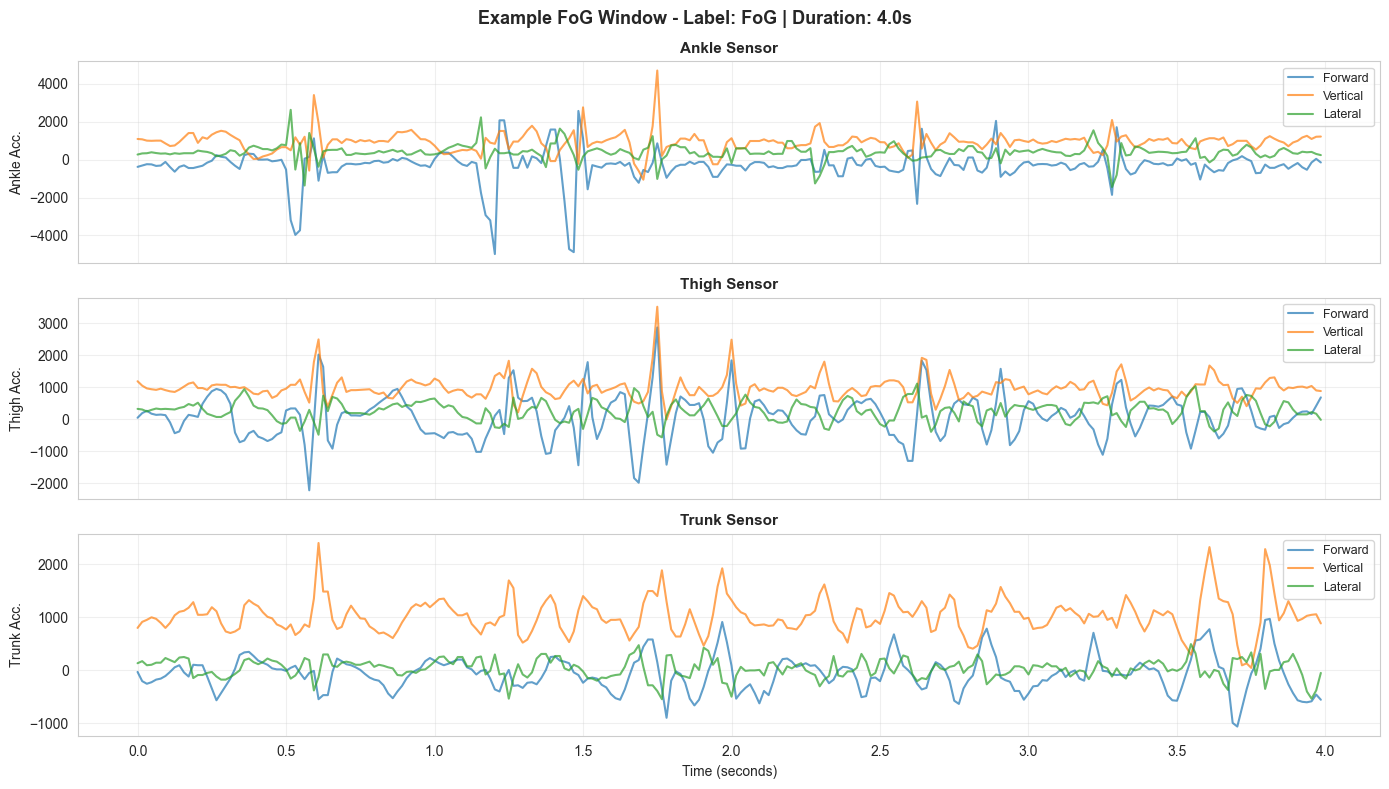

In [7]:
# Visualize example windows
from utils.constants import LABEL_NAMES_BINARY, LABEL_NAMES_MULTICLASS

# Find a FoG window
fog_indices = np.where(binary_labels == 1)[0]
if len(fog_indices) > 0:
    idx = fog_indices[0]
    example_window = binary_windows[idx]
    example_label = binary_labels[idx]
    
    # Plot window
    n_samples, n_channels = example_window.shape
    time_axis = np.arange(n_samples) / SAMPLING_RATE
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
    sensors = ['Ankle', 'Thigh', 'Trunk']
    colors = ['steelblue', 'coral', 'gold']
    
    for i in range(3):
        # Plot three axes for each sensor
        sensor_data = example_window[:, i*3:(i+1)*3]
        axes[i].plot(time_axis, sensor_data[:, 0], label='Forward', alpha=0.7)
        axes[i].plot(time_axis, sensor_data[:, 1], label='Vertical', alpha=0.7)
        axes[i].plot(time_axis, sensor_data[:, 2], label='Lateral', alpha=0.7)
        axes[i].set_ylabel(f'{sensors[i]} Acc.')
        axes[i].set_title(f'{sensors[i]} Sensor', fontsize=11, fontweight='bold')
        axes[i].legend(loc='upper right', fontsize=9)
        axes[i].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time (seconds)')
    plt.suptitle(f'Example FoG Window - Label: {LABEL_NAMES_BINARY[example_label]} | Duration: {WINDOW_SIZE_SEC}s', 
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No FoG windows found.")

## 4. Create LOSO Splits

Leave-One-Subject-Out cross-validation: each subject is held out as test set once.

In [ ]:
# Create LOSO splits with different overlap for train/test
print("Creating LOSO splits with different overlap strategies...")
print("  Train: 50% overlap (more data)")
print("  Test: 0% overlap (realistic evaluation, no temporal correlation)")
print("="*70)

subjects_list = sorted(df['subject'].unique())
loso_splits_binary = []
loso_splits_multiclass = []

for fold, test_subject in enumerate(subjects_list):
    # Split dataframe by subject
    train_subjects = [s for s in subjects_list if s != test_subject]
    df_train = df[df['subject'].isin(train_subjects)].reset_index(drop=True)
    df_test  = df[df['subject'] == test_subject].reset_index(drop=True)

    # Create train windows with 50% overlap (binary + multiclass in one call)
    result_train = window_creator_train.create_windows_from_df(
        df=df_train,
        feature_cols=FEATURE_COLUMNS,
        binary_label_col='binary_label',
        multiclass_label_col='multiclass_label',
        subject_col='subject',
        trial_col='trial'
    )

    # Create test windows with 0% overlap
    result_test = window_creator_test.create_windows_from_df(
        df=df_test,
        feature_cols=FEATURE_COLUMNS,
        binary_label_col='binary_label',
        multiclass_label_col='multiclass_label',
        subject_col='subject',
        trial_col='trial'
    )

    # Binary split
    split_binary = {
        'fold': fold,
        'test_subject': test_subject,
        'X_train': result_train['binary']['windows'],
        'X_test':  result_test['binary']['windows'],
        'y_train': result_train['binary']['labels'],
        'y_test':  result_test['binary']['labels'],
        'subjects_train': result_train['binary']['subjects'],
        'subjects_test':  result_test['binary']['subjects'],
        'train_dist': np.bincount(result_train['binary']['labels'], minlength=2),
        'test_dist':  np.bincount(result_test['binary']['labels'],  minlength=2)
    }
    loso_splits_binary.append(split_binary)

    # Multiclass split
    split_multiclass = {
        'fold': fold,
        'test_subject': test_subject,
        'X_train': result_train['multiclass']['windows'],
        'X_test':  result_test['multiclass']['windows'],
        'y_train': result_train['multiclass']['labels'],
        'y_test':  result_test['multiclass']['labels'],
        'subjects_train': result_train['multiclass']['subjects'],
        'subjects_test':  result_test['multiclass']['subjects'],
        'train_dist': np.bincount(result_train['multiclass']['labels'], minlength=3),
        'test_dist':  np.bincount(result_test['multiclass']['labels'],  minlength=3)
    }
    loso_splits_multiclass.append(split_multiclass)

    print(f"Fold {fold}: Test={test_subject} | "
          f"Train={split_binary['X_train'].shape[0]} (50% overlap) | "
          f"Test={split_binary['X_test'].shape[0]} (0% overlap) | "
          f"test_dist={split_binary['test_dist']}")

print(f"\nBinary LOSO splits created: {len(loso_splits_binary)} folds")

In [ ]:
print(f"Multiclass LOSO splits created: {len(loso_splits_multiclass)} folds")

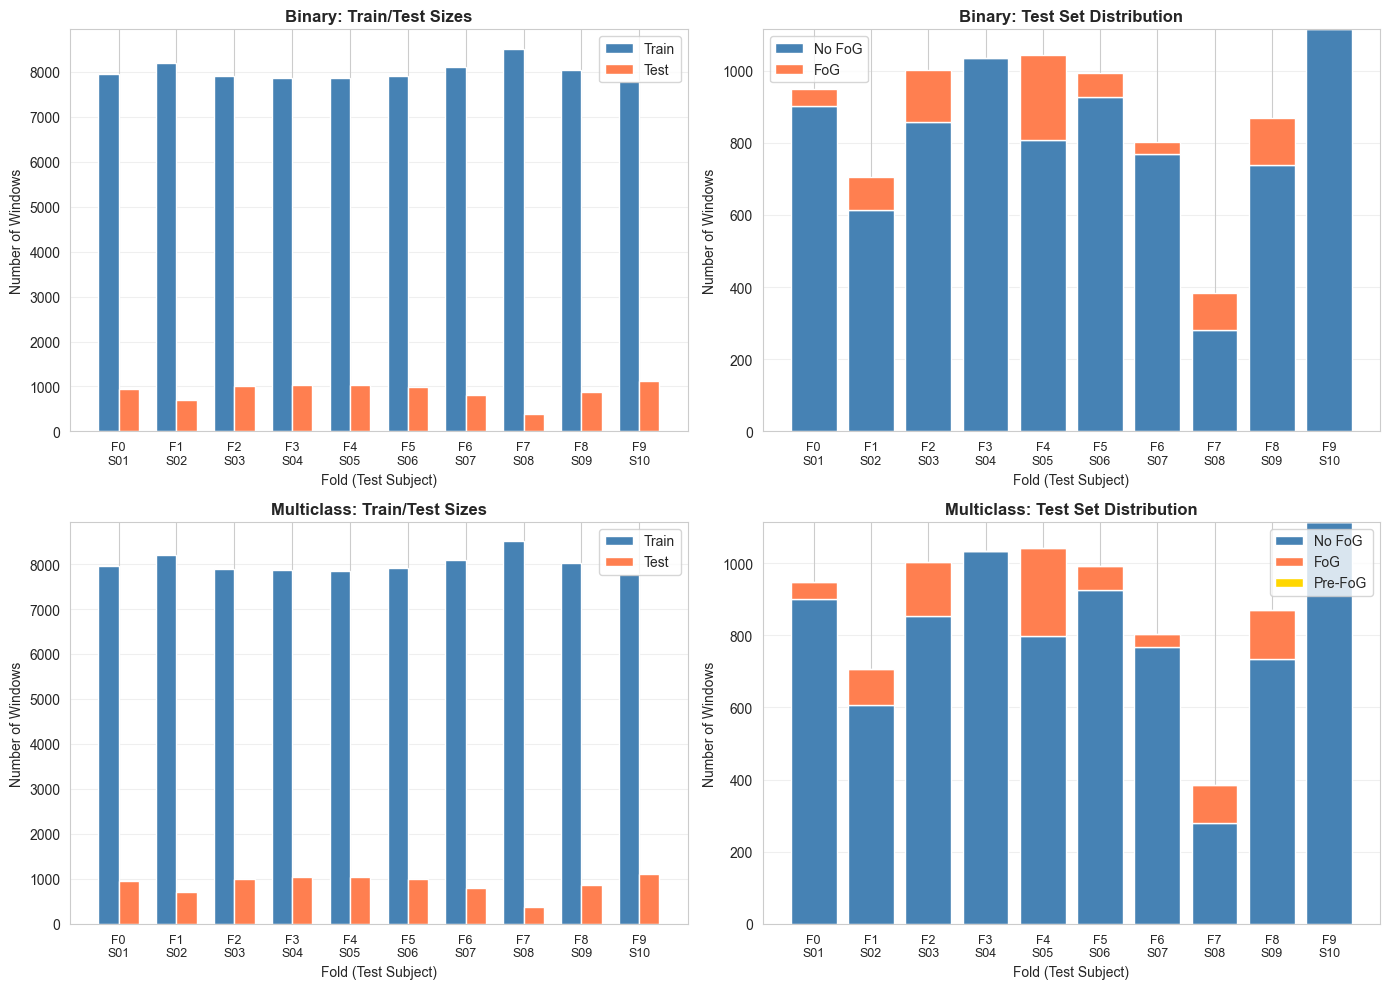

In [10]:
# Visualize LOSO splits
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Binary: Train/Test sizes
train_sizes = [split['X_train'].shape[0] for split in loso_splits_binary]
test_sizes = [split['X_test'].shape[0] for split in loso_splits_binary]
test_subjects = [split['test_subject'] for split in loso_splits_binary]

x = np.arange(len(loso_splits_binary))
width = 0.35

axes[0, 0].bar(x - width/2, train_sizes, width, label='Train', color='steelblue')
axes[0, 0].bar(x + width/2, test_sizes, width, label='Test', color='coral')
axes[0, 0].set_xlabel('Fold (Test Subject)')
axes[0, 0].set_ylabel('Number of Windows')
axes[0, 0].set_title('Binary: Train/Test Sizes', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels([f"F{i}\n{s}" for i, s in enumerate(test_subjects)], fontsize=9)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Binary: Test distribution
for i, split in enumerate(loso_splits_binary):
    dist = split['test_dist']
    axes[0, 1].bar(i, dist[0], color='steelblue', label='No FoG' if i == 0 else '')
    axes[0, 1].bar(i, dist[1], bottom=dist[0], color='coral', label='FoG' if i == 0 else '')

axes[0, 1].set_xlabel('Fold (Test Subject)')
axes[0, 1].set_ylabel('Number of Windows')
axes[0, 1].set_title('Binary: Test Set Distribution', fontweight='bold')
axes[0, 1].set_xticks(range(len(loso_splits_binary)))
axes[0, 1].set_xticklabels([f"F{i}\n{s}" for i, s in enumerate(test_subjects)], fontsize=9)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Multiclass: Train/Test sizes
train_sizes_m = [split['X_train'].shape[0] for split in loso_splits_multiclass]
test_sizes_m = [split['X_test'].shape[0] for split in loso_splits_multiclass]

axes[1, 0].bar(x - width/2, train_sizes_m, width, label='Train', color='steelblue')
axes[1, 0].bar(x + width/2, test_sizes_m, width, label='Test', color='coral')
axes[1, 0].set_xlabel('Fold (Test Subject)')
axes[1, 0].set_ylabel('Number of Windows')
axes[1, 0].set_title('Multiclass: Train/Test Sizes', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([f"F{i}\n{s}" for i, s in enumerate(test_subjects)], fontsize=9)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Multiclass: Test distribution
for i, split in enumerate(loso_splits_multiclass):
    dist = split['test_dist']
    bottom = 0
    colors = ['steelblue', 'coral', 'gold']
    labels = ['No FoG', 'FoG', 'Pre-FoG']
    for j, (count, color, label) in enumerate(zip(dist, colors, labels)):
        axes[1, 1].bar(i, count, bottom=bottom, color=color, 
                      label=label if i == 0 else '')
        bottom += count

axes[1, 1].set_xlabel('Fold (Test Subject)')
axes[1, 1].set_ylabel('Number of Windows')
axes[1, 1].set_title('Multiclass: Test Set Distribution', fontweight='bold')
axes[1, 1].set_xticks(range(len(loso_splits_multiclass)))
axes[1, 1].set_xticklabels([f"F{i}\n{s}" for i, s in enumerate(test_subjects)], fontsize=9)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Summary Statistics

In [ ]:
# Summary
total_train_bin = sum([split['X_train'].shape[0] for split in loso_splits_binary])
total_test_bin  = sum([split['X_test'].shape[0]  for split in loso_splits_binary])

print("="*70)
print("PREPROCESSING SUMMARY")
print("="*70)

print(f"\nOriginal dataset:")
print(f"  Samples: {len(df):,}")
print(f"  Subjects: {df['subject'].nunique()}")

print(f"\nWindow creation strategy:")
print(f"  Configuration: {WINDOW_SIZE_SEC}s")
print(f"  Train overlap: {WINDOW_OVERLAP_TRAIN*100:.0f}% (step: {int(WINDOW_SIZE_SEC * SAMPLING_RATE * (1 - WINDOW_OVERLAP_TRAIN))} samples)")
print(f"  Test overlap:  {WINDOW_OVERLAP_TEST*100:.0f}% (no temporal correlation between test windows)")
print(f"  Window shape: ({config['window_samples']} samples, {len(FEATURE_COLUMNS)} features)")

print(f"\nLOSO splits:")
print(f"  Folds: {len(loso_splits_binary)}")
print(f"  Avg train windows/fold: {total_train_bin/len(loso_splits_binary):.0f}")
print(f"  Avg test windows/fold:  {total_test_bin/len(loso_splits_binary):.0f}")
print(f"  Total unique test windows: {total_test_bin:,}")

# Aggregate class balance from non-overlapping test windows
all_test_y = np.concatenate([split['y_test'] for split in loso_splits_binary])
print(f"\nClass balance (aggregated test windows, binary):")
print(f"  No FoG: {np.sum(all_test_y == 0):,} ({np.sum(all_test_y == 0)/len(all_test_y)*100:.1f}%)")
print(f"  FoG:    {np.sum(all_test_y == 1):,} ({np.sum(all_test_y == 1)/len(all_test_y)*100:.1f}%)")
print("="*70)

## 6. Save Processed Data

In [12]:
# Create output directory
output_dir = Path('../../outputs/datasets_csv')
output_dir.mkdir(parents=True, exist_ok=True)

# Save labeled dataset
csv_path = output_dir / 'daphnet_segmented_dataset.csv'
df.to_csv(csv_path, index=False)
print(f"Labeled dataset saved: {csv_path}")
print(f"  Samples: {len(df):,}")
print(f"  Columns: {len(df.columns)}")

# Save binary LOSO splits
binary_path = output_dir / 'daphnet_loso_windows_binary.pkl'
with open(binary_path, 'wb') as f:
    pickle.dump(loso_splits_binary, f)
print(f"\nBinary LOSO splits saved: {binary_path}")
print(f"  Folds: {len(loso_splits_binary)}")
print(f"  Total windows: {sum([len(s['y_train']) + len(s['y_test']) for s in loso_splits_binary]):,}")

# Save multiclass LOSO splits
multiclass_path = output_dir / 'daphnet_loso_windows_multiclass.pkl'
with open(multiclass_path, 'wb') as f:
    pickle.dump(loso_splits_multiclass, f)
print(f"\nMulticlass LOSO splits saved: {multiclass_path}")
print(f"  Folds: {len(loso_splits_multiclass)}")
print(f"  Total windows: {sum([len(s['y_train']) + len(s['y_test']) for s in loso_splits_multiclass]):,}")

print("\n" + "="*70)
print("All data saved successfully.")
print("="*70)

Labeled dataset saved: ../../outputs/datasets_csv/daphnet_segmented_dataset.csv
  Samples: 1,140,835
  Columns: 20

Binary LOSO splits saved: ../../outputs/datasets_csv/daphnet_loso_windows_binary.pkl
  Folds: 10
  Total windows: 88,950

Multiclass LOSO splits saved: ../../outputs/datasets_csv/daphnet_loso_windows_multiclass.pkl
  Folds: 10
  Total windows: 88,950

All data saved successfully.


## Summary

**Completed preprocessing pipeline:**

1. Loaded Daphnet dataset and filtered experimental data
2. Created binary (No FoG/FoG) and multiclass (No FoG/FoG/Pre-FoG) labels
3. Generated sliding windows (4s, 50% overlap) per subject/trial
4. Created 10 LOSO folds for subject-independent validation
5. Saved labeled dataset and windowed LOSO splits

**Data structure:**
- Each fold contains train/test windows with shape (n_windows, 256, 9)
- Windows maintain temporal continuity within subject/trial boundaries
- No data leakage: test subjects completely isolated in each fold

**Next step:** Feature extraction from windowed data (notebook 03)